#Import libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # for spliting
import random

#fix the seed to 42 to make my result reproducible
np.random.seed(42)
random.seed(42)

In [ ]:
# !pip install line_profiler
# %load_ext line_profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.6 MB/s eta 0:00:00


#Data Processing


In [3]:
# upload the dataset
data=pd.read_csv("ratings.csv")
data.head()
print(data.shape) # print the shape of the dataset

(100836, 4)


In [4]:
# we create a new numerotation in order to run over matrix factorization model

n_users=data["userId"].value_counts().shape[0] # count the number of users
n_items=data["movieId"].value_counts().shape[0] # count the number of movie
print(f"the number of users:{n_users},\nthe number of movies:{n_items}")

# we create a new numerotation

user_ids = sorted(data['userId'].unique())
movie_ids = sorted(data['movieId'].unique())

user_to_index = {uid: i for i, uid in enumerate(user_ids)}
movie_to_index = {mid: j for j, mid in enumerate(movie_ids)}



# add new indexation  notation to link matrix U,V and ratings matrix

data['user_idx'] = data['userId'].map(user_to_index)
data['movie_idx'] = data['movieId'].map(movie_to_index)


the number of users:610,
the number of movies:9724


In [5]:
data.head() # visualize the new dataset

,userId,movieId,rating,timestamp,user_idx,movie_idx
0,1,1,4.0,964982703,0,0
1,1,3,4.0,964981247,0,2
2,1,6,4.0,964982224,0,5
3,1,47,5.0,964983815,0,43
4,1,50,5.0,964982931,0,46


In [6]:
# split data into training and test set. we ensure that each movie and each user is present in the train data.

# We use the train set to build matrix, and we see how it perform for movies in the test dataset  .


train_list_g = []
test_list_R = []

# First, guarantee each movie appears in train
for movie_id, group in data.groupby('movieId'):
    train_sample = group.sample(n=1, random_state=42) # select randomly one rating of the movie
    train_list_g.append(train_sample) # add the selected rating in the train set
    remaining = group.drop(train_sample.index) # remove the selected rating to avoid multiple selection
    test_list_R.append(remaining)
    # group.reset_index(drop=True)

train_data_g = pd.concat(train_list_g,axis=0) # put all the selected rating in the dataset in a dataframe
remaining_data = pd.concat(test_list_R,axis=0)

#..................

# sample the remaining data normally per users. Now we ensure that each user appears

train_list = []
test_list = []

for user_id, group in remaining_data.groupby('userId'): #group by user
    train, test = train_test_split(group, test_size=0.4, random_state=42) # select 60% of the  remaining rating for user_id
    train_list.append(train)
    test_list.append(test)

train_list.append(train_data_g) # we add  the first occurrence of each movies that we sampled earlier
train_data = pd.concat(train_list,axis=0)[["userId",	"movieId",	"rating","user_idx","movie_idx"]]
test_data = pd.concat(test_list,axis=0)[["userId",	"movieId",	"rating","user_idx","movie_idx"]]



In [7]:
print(train_data.shape, test_data.shape) # see the shape of our training and test set

(64152, 5) (36684, 5)


In [8]:
# when we display the result, we see that all users are present and each movie is selected alt least once.
# print("training data",train_data.head())
print("number of users train",train_data["userId"].value_counts().shape[0])
print("number of movies train",train_data["movieId"].value_counts().shape[0])
print("number of users test",test_data["userId"].value_counts().shape[0])
print("number of movies test",test_data["movieId"].value_counts().shape[0])

number of users train 610
number of movies train 9724
number of users test 610
number of movies test 4992


# Matrix factorization approch

Let M be a matrix contening our rating for each user. M is partially observed.

We assume that $M=UV^{T}$ where $U \in \mathbb{R}^{n \times k}$ is the user preference and $V \in \mathbb{R}^{m \times k}$ movies features that are relevant for decision.  

The linear combinaition of the prefernces and the feature  gives the rating.

###Minimization problem

We  want to minimize $ loss=\|M-UV^{T}\|_{F}^{2}+\lambda(\| U\|_F^2+\| V\|_F^2)$

We are going to use gradient descent algorthm

### gradient of loss

$\nabla_{U_i}loss =\nabla_{U_i}\big((M_{i,j}-U_iV_j^T)^2 + \lambda (U_i^TU_i+ V_j^TV_j)\big)$

$\nabla_{U_i}loss=-2V_j(M_{i,j}-U_iV_j^T)+2 \lambda U_i = -2 (V_j(M_{i,j}-U_iV_j^T)-\lambda U_i)=-2 (e_{ij}V_j-\lambda U_i)$

where $e_{ij}=M_{i,j}-U_iV_j^T$


similarly

$\nabla_{V_j}loss=-2U_i(M_{i,j}-U_iV_j^T)+2 \lambda V_j = -2 (U_i(M_{i,j}-U_iV_j^T)-\lambda V_j)=-2 (e_{ij}U_i-\lambda V_j)$


###parameter update:

$U_i=U_i-\beta \nabla_{U_i}loss$

$V_j=V_j-\beta \nabla_{V_j}loss$






#utility function

In [ ]:
def gradiant(er,U,V,lamb):
  ''' this function compute the gradient for user i and movie j parameters and return them
  er: prediction error for movie j and user i
  U:latten factor for user i
  V:latten factor for movie j'''

  grad_u=2*(er*V- lamb * U)
  grad_v=2*(er*U- lamb * V)

  return grad_u,grad_v


In [ ]:
def Matrix_fac(X,n_users,n_items,K,lr,lamb,N):
    ''' This function implement gradient descent to solve the minimization problem of matrix factorization
    n_users: number of user
    n_items: number of movies
    K: the rank of the matrix factorization
    lr: learning rate for gradient descent
    lamb: regularization parameter
    '''
    my_dict_pred_rank = {}
    my_dict_error_rank = []
    # K_num = np.arange(2,10,1)

    norm_r=np.linalg.norm(X["rating"].values)

    plt.close('all')
    plt.figure(figsize=(8,5))

    for k in K:
      U = np.random.normal(0, 0.1, (n_users, k))
      V = np.random.normal(0, 0.1, (n_items, k))


      # epoch_num=np.arange(0,N,1)
      my_dict_pred = {}
      my_dict_error = []

      for epoch in range(N):
        for row in X[["user_idx","movie_idx","rating"]].itertuples(index=False):

            i, j, r=row
            # print(type(i))

            # prediction
            M_pred = U[i].dot(V[j])
            err = r - M_pred

            # updates
            grad=gradiant(err,U[i],V[j],lamb)

            U[i] += lr * grad[0]
            V[j] += lr * grad[1]


        # save the matrix prediction at that epoch

        my_dict_pred[epoch]=(U.copy(),V.copy())


        # compute the error prediction at that epoch
        error = 0
        # norm_r=0
        for i, j, r in zip(X["user_idx"],
                          X["movie_idx"],
                          X["rating"]):
            pred = U[i].dot(V[j])
            error += (r - pred) ** 2
            # norm_r +=r**2
        my_dict_error.append(error**(0.5)/norm_r)


      # best model
      best_epoch = np.argmin(my_dict_error)
      # print(best_epoch)
      my_dict_pred_rank[k] = my_dict_pred[best_epoch]
      my_dict_error_rank.append(my_dict_error[best_epoch])

      #  plot the error per after each iteration
      plt.plot(np.arange(N),my_dict_error, label=f"rank = {k}")


    plt.xlabel("Iteration")
    plt.ylabel("error")
    plt.title("error vs iteration by rank")
    plt.legend()
    plt.savefig("MF_error_vs_iteration.png", dpi=300, bbox_inches="tight")
    # plt.show()




    return my_dict_pred_rank,my_dict_error_rank,my_dict_error







#parameters

In [ ]:
n_users=data["userId"].value_counts().shape[0]
n_items=data["movieId"].value_counts().shape[0]
K = np.arange(3,10,1)  # rang of the matrix

# hyperparameters
lr = 0.0001
lamb = 0.005
N=100


##train section for matrix factorization

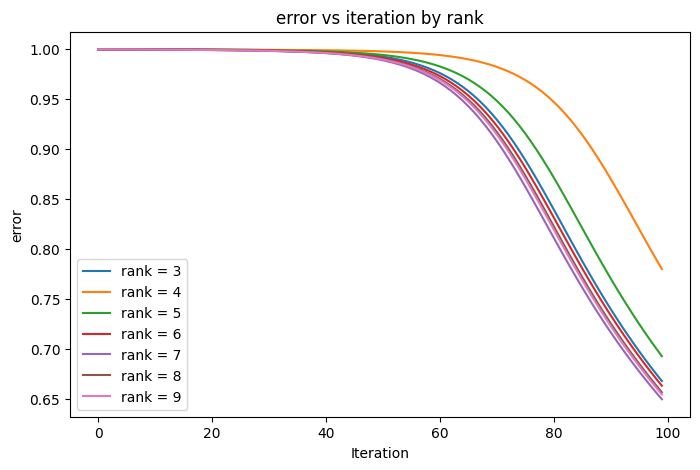

In [ ]:
matrix_fact_res=Matrix_fac(train_data,n_users,n_items,K,lr,lamb,N)

In [ ]:
# the best model is the one with e=rank equal to 7
K = np.array([7])
matrix_fact_res=Matrix_fac(train_data,n_users,n_items,K,lr,lamb,N)

##test section for matrix factorization

In [ ]:
# compute the relative error on test data
U, V = matrix_fact_res[0][7]
X_hat = U @ V.T   # prediction

# convert the np.array to datafraame and add the index
X_hat_df = pd.DataFrame(
    X_hat,
    index=range(n_users),
    columns=range(n_items)
)

# Align the predicted matrix with test matrix
M_test = test_data.pivot_table(
    index="user_idx",
    columns="movie_idx",
    values="rating",
    fill_value=0
)

X_hat_df = X_hat_df.loc[M_test.index, M_test.columns]# select only movie in the test data set

# Mask observed entries
mask = M_test.values != 0

diff = (X_hat_df.values - M_test.values) * mask # compute the difference only where the value of the test was given not on missing rating

error_test_MF = np.linalg.norm(diff,'fro') / (np.linalg.norm(M_test.values * mask,'fro')) #compute the recovery error

print(f"Recovery error on test data  is {error_test_MF}")

Recovery error on test data  is 0.6288998615010296


In [ ]:
# compute the relative error on  overall datadset (training + test set)
U, V = matrix_fact_res[0][7]
X_hat = U @ V.T   # prediction

#  put convert the np.array to datafraame and add the index
X_hat_df = pd.DataFrame(
    X_hat,
    index=range(n_users),
    columns=range(n_items)
)

# Align with test matrix
M_test = data.pivot_table(
    index="user_idx",
    columns="movie_idx",
    values="rating",
    fill_value=0
)

X_hat_df = X_hat_df.loc[M_test.index, M_test.columns]

# Mask for observed entries
mask = M_test.values != 0

diff = (X_hat_df.values - M_test.values) * mask

error_test_MF = np.linalg.norm(diff,'fro') / (np.linalg.norm(M_test.values * mask,'fro'))

print(f"Recovery error on test data  is {error_test_MF}")

Recovery error on test data  is 0.663676860601844


#FISTA ALgorithm for nuclear norm minimization


In [9]:
# change the format of the data, now (i,j) represent rating of  users i for movie j
M=train_data.pivot_table(index='userId', columns='movieId', values='rating',fill_value=0)
M.head()
M.shape

(610, 9724)

In [10]:
# this function is equivalent to a projection matrix
def mask_nonzero_entries(A, keep_ratio=0.7):
  '''define a matrix which is is going to hid 1-keep_ratio of the observed rating.
  this matrix has 1 where we want the rating to be see and  '''
  A = A.copy()

  # Get indices of non-zero entries
  nonzero_indices = np.argwhere(A != 0)

  # Number of entries to keep
  num_keep = int(len(nonzero_indices) * keep_ratio)

  # Randomly select indices to keep
  selected_indices = nonzero_indices[np.random.choice(
      len(nonzero_indices), num_keep, replace=False
  )]

  # Create mask (all zeros)
  mask = np.zeros_like(A, dtype=bool)

  # Set selected positions to 1
  for i, j in selected_indices:
      mask[i, j] = 1

  return mask



In [ ]:
mask_nonzero_entries(M.values, keep_ratio=1)# vizualisation

array([[ True, False,  True, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

###Utilities functions

In [11]:
def power_method(A, tol=1e-6, IterMax=100):
    '''compute the largest eigenvalue'''
    y = np.random.rand(A.shape[0])
    x_k = y / (np.linalg.norm(y) + 1e-8)

    for _ in range(IterMax):
        y = x_k
        x_k = A @ x_k
        x_k = x_k / (np.linalg.norm(x_k) + 1e-8)

        if np.linalg.norm(x_k - y) < tol:
            break

    # eigenvalue
    eigval = x_k.T @ A @ x_k

    return eigval, x_k



def svd_decomp(X,tol=1e-6, num_iter=100):
    """
    Approximate top-k singular values/vectors of X

    Returns:
        U, s, Vt
    """

    m, n = X.shape
    A = X.T @ X   # symmetric (n x n)  and eigen value of A.TA are square of singular value of A

    V = []
    U = []
    s = []

    A_work = A.copy()

    for _ in range(min(m, n)):
        # --- largest eigenpair of X^T X ---
        eigval, v = power_method(A_work,tol, num_iter)
        v = v / (np.linalg.norm(v)+ 1e-8) # we add 1e-8 to denominator to avoid division by 0

        sigma = np.sqrt(max(eigval, 0))

        if sigma < 1e-6:
            break

        # compute the left singular vector
        u = X @ v / sigma

        V.append(v)
        U.append(u)
        s.append(sigma)

        # remove the computed eigval value ---
        A_work = A_work - eigval * np.outer(v, v)
        # A_work = (A_work + A_work.T) / 2  # keep symmetry
    if len(s) == 0:
      return np.zeros((m,0)), np.array([]), np.zeros((0,n))


    U = np.column_stack(U)
    V = np.column_stack(V)
    s = np.array(s)
    Vt = V.T


    return U, s, Vt

In [13]:
def svt_operator_scratch(X, tau,tol=1e-6):
    """Singular value thresholding """
    m, n = X.shape

    # partial SVD decomposition

    U, s, Vt = svd_decomp(X,tol, num_iter=1000)

    s_thresh = np.maximum(s - tau, 0)
    r = np.sum(s_thresh > 1e-12)

    if r == 0:
        return np.zeros_like(X)
    return U[:, :r] @ np.diag(s_thresh[:r]) @ Vt[:r, :]

In [14]:
def svt_operator(X, tau):
    """Singular value thresholding with python function
    X: matrix to decompose
    tau: regularization parameter
    """
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    s_thresh = np.maximum(s - tau, 0)
    return U @ np.diag(s_thresh) @ Vt

In [15]:
def fista_MC_algorithm(M, Omega, tau=1.0, L=1.0, T=100, tol=1e-5):
    """
    FISTA for nuclear norm minimization

    min_X tau * ||X||_* + (1/2)||A(X) - y||^2

      Parameters
    ----------
    M : ndarray
        truth matrix (only Omega entries are used)
    Omega : boolean mask
        True where entries are observed
    tau : float
        Nuclear norm regularization
    L : float
        Lipschitz constant (for projection operator = 1)
    T : int
        Max iterations
    tol : float
        Convergence tolerance

    Returns
    -------
    X  and error per iteration: reconstructed matrix
    """

    Xk = np.zeros_like(M)
    Rk = np.zeros_like(M)
    # print(Xk.shape)
    # return 0
    tk = 1
    my_dict_error={}

    plt.close('all')
    plt.figure(figsize=(8,5))

    for k in range(T):
      # print(type(k))
      grad = np.zeros_like(M)
      grad[Omega] = Rk[Omega] - M[Omega] # compute the gradient
      Y = Rk - grad / L # apply gradient descent

      X_next = svt_operator(Y, tau / L) # apply proximal operator

      t_next = (1 + np.sqrt(1 + 4 * tk**2)) / 2 # compute the momentum
      R_next = X_next + ((tk - 1) / t_next) * (X_next - Xk)

      # skip first iteration
      if k > 10:
          cvg = np.linalg.norm(X_next - Xk, 'fro') / (np.linalg.norm(X_next, 'fro') + 1e-8)
          if cvg < tol:
              print(f"Converged at iteration {k}")
              break


      #save the error after each iteration

      my_dict_error[k]=np.linalg.norm(X_next[Omega] - M[Omega],2) / np.linalg.norm(M[Omega],2)


      Xk = X_next
      Rk = R_next
      tk = t_next

    return Xk,my_dict_error

###Application

##trainning section for nuclear norm

In [16]:
# prepare our data in order to run our model
# rating matrix as n* m matrix, n users and movies columns
X = M.values

# Mask (keep all the entry of training)
Omega = mask_nonzero_entries(M.values, keep_ratio=1)

M_obs = np.zeros_like(M)
M_obs= X*Omega

vec_error=[]
T=100 #number of iteration

In [ ]:
# try different value for the penalization parameter
for tau in np.linspace(0.001,0.01,4):
  X_hat = fista_MC_algorithm(M_obs, Omega, tau=tau, L=1, T=100, tol=1e-5)[0]
  vec_error.append(np.linalg.norm((X_hat - X)*Omega,'fro') / np.linalg.norm(M_obs,'fro'))
  # Error
  print(f"Recovery error for tau=  {tau}  is  {np.linalg.norm((X_hat - M_obs)*Omega,'fro') / np.linalg.norm(M_obs,'fro')}")

#plot of error by penalisation factor
plt.plot(np.linspace(0.001,0.01,4),vec_error)
plt.xlabel("tau")
plt.ylabel("relative error")
plt.title("relative error vs penalization parameter")
# plt.legend()
# plt.savefig("NM_error_vs_penalization.png")
plt.show()




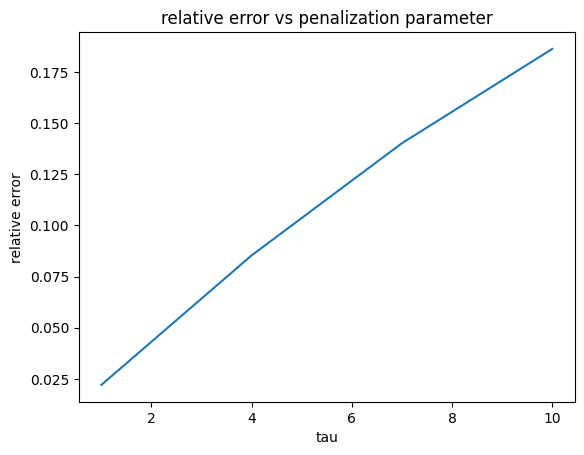

np.int64(64)

In [ ]:
for tau in np.linspace(1,10,4):
  X_hat = fista_MC_algorithm(M_obs, Omega, tau=tau, L=1, T=100, tol=1e-5)[0]
  vec_error.append(np.linalg.norm((X_hat - X)*Omega,'fro') / np.linalg.norm(M_obs,'fro'))
  # Error
  print(f"Recovery error for tau=  {tau}  is  {np.linalg.norm((X_hat - M_obs)*Omega,'fro') / np.linalg.norm(M_obs,'fro')}")

#plot of error by penalisation factor
plt.plot(np.linspace(1,10,4),vec_error)
plt.xlabel("tau")
plt.ylabel("relative error")
plt.title("relative error vs penalization parameter")
# plt.legend()
# plt.savefig("NM_error_vs_penalization.png")
plt.show()


# the rank of the predicted matrix
np.linalg.matrix_rank(X_hat)

In [ ]:
#the selected  model  is the one with tau=10
X_hat_NM,my_dict_error = fista_MC_algorithm(M_obs, Omega, tau=10, L=1, T=100, tol=1e-5)


<Figure size 800x500 with 0 Axes>

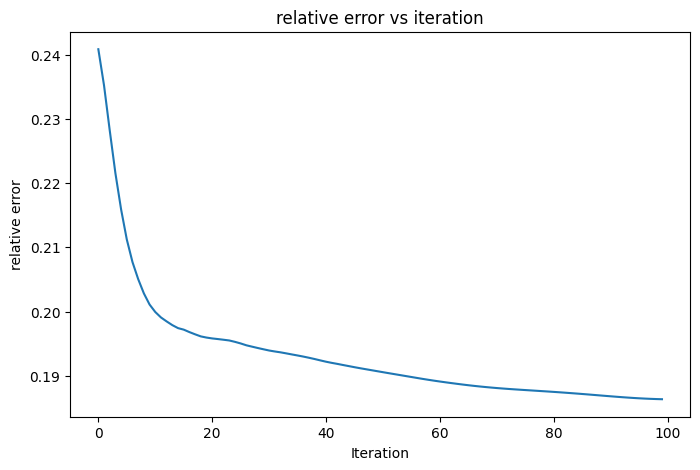

In [ ]:
#plot the error per after each iteration
plt.plot(np.arange(T),list(my_dict_error.values()))
plt.xlabel("Iteration")
plt.ylabel("relative error")
plt.title("relative error vs iteration")
# plt.legend()
# plt.show()
plt.savefig("NM_error_vs_iteration_10.png")


##test section for nuclear norm

In [ ]:
# compute the relative error on test data and overall dataset

# relative error on test set only
ui = test_data["user_idx"].astype(int).values
mi = test_data["movie_idx"].astype(int).values
ratings_test = test_data["rating"].values

preds_test = X_hat_NM[ui, mi]

error_test = np.linalg.norm(ratings_test - preds_test) / np.linalg.norm(ratings_test)

# relative error on overall dataset
ui = data["user_idx"].astype(int).values
mi = data["movie_idx"].astype(int).values
ratings = data["rating"].values

preds = X_hat_NM[ui, mi]

error = np.linalg.norm(ratings - preds) / np.linalg.norm(ratings)
print(error_test,error)


In [ ]:
# rank of the predicted matrix
print(np.linalg.matrix_rank(X_hat_NM))

64
